## ========================================================================
## 1. Import Library
## ========================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif

pd.set_option('display.max_columns', None)

## ========================================================================
## 2. Baca Dataset
## ========================================================================

In [2]:
df = pd.read_excel("CADalizadeh.xls")

## ========================================================================
## 3. EDA
## ========================================================================

Dimensi (baris, kolom): (303, 56)
Jumlah atribut (kolom): 56
Jumlah data (baris): 303

Contoh 5 baris awal:


,No,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,Obesity,CRF,CVA,Airway disease,Thyroid Disease,CHF,DLP,BP,PR,Edema,Weak Peripheral Pulse,Lung rales,Systolic Murmur,Diastolic Murmur,Typical Chest Pain,Dyspnea,Function Class,Atypical,Nonanginal,Exertional CP,LowTH Ang,Q Wave,St Elevation,St Depression,Tinversion,LVH,Poor R Progression,FBS,CR,TG,LDL,HDL,BUN,ESR,HB,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
0,1,53,90,175,Male,29.387755,0,1,1,0,0,Y,N,N,N,N,N,Y,110,80,0,N,N,N,N,0,N,0,N,N,N,N,0,0,1,1,N,N,90,0.7,250,155,30.0,8,7,15.6,4.7,141,5700,39,52,261,50,0,N,Cad
1,2,67,70,157,Fmale,28.398718,0,1,0,0,0,Y,N,N,N,N,N,N,140,80,1,N,N,N,N,1,N,0,N,N,N,N,0,0,1,1,N,N,80,1.0,309,121,36.0,30,26,13.9,4.7,156,7700,38,55,165,40,4,N,Cad
2,3,54,54,164,Male,20.077335,0,0,1,0,0,N,N,N,N,N,N,N,100,100,0,N,N,N,N,1,N,0,N,N,N,N,0,0,0,0,N,N,85,1.0,103,70,45.0,17,10,13.5,4.7,139,7400,38,60,230,40,2,mild,Cad
3,4,66,67,158,Fmale,26.838648,0,1,0,0,0,Y,N,N,N,N,N,N,100,80,0,N,N,N,Y,0,Y,3,N,Y,N,N,0,0,1,0,N,N,78,1.2,63,55,27.0,30,76,12.1,4.4,142,13000,18,72,742,55,0,Severe,Normal
4,5,50,87,153,Fmale,37.165193,0,1,0,0,0,Y,N,N,N,N,N,N,110,80,0,N,N,Y,N,0,Y,2,N,N,N,N,0,0,0,0,N,N,104,1.0,170,110,50.0,16,27,13.2,4.0,140,9200,55,39,274,50,0,Severe,Normal



Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 56 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   No                     303 non-null    int64  
 1   Age                    303 non-null    int64  
 2   Weight                 303 non-null    int64  
 3   Length                 303 non-null    int64  
 4   Sex                    303 non-null    str    
 5   BMI                    303 non-null    float64
 6   DM                     303 non-null    int64  
 7   HTN                    303 non-null    int64  
 8   Current Smoker         303 non-null    int64  
 9   EX-Smoker              303 non-null    int64  
 10  FH                     303 non-null    int64  
 11  Obesity                303 non-null    str    
 12  CRF                    303 non-null    str    
 13  CVA                    303 non-null    str    
 14  Airway disease         303 non-null    str    
 15  Th

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,303.0,NaN,NaN,NaN,152.0,87.612784,1.0,76.5,152.0,227.5,303.0
Age,303.0,NaN,NaN,NaN,58.89769,10.392278,30.0,51.0,58.0,66.0,86.0
Weight,303.0,NaN,NaN,NaN,73.831683,11.987358,48.0,65.0,74.0,81.0,120.0
Length,303.0,NaN,NaN,NaN,164.716172,9.327661,140.0,158.0,165.0,171.0,188.0
Sex,303,2,Male,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,303.0,NaN,NaN,NaN,27.248339,4.098865,18.115413,24.51438,26.77551,29.411765,40.900658
DM,303.0,NaN,NaN,NaN,0.29703,0.457706,0.0,0.0,0.0,1.0,1.0
HTN,303.0,NaN,NaN,NaN,0.590759,0.492507,0.0,0.0,1.0,1.0,1.0
Current Smoker,303.0,NaN,NaN,NaN,0.207921,0.406491,0.0,0.0,0.0,0.0,1.0
EX-Smoker,303.0,NaN,NaN,NaN,0.033003,0.178941,0.0,0.0,0.0,0.0,1.0



Jumlah missing value per kolom (top 20):


No                 0
Age                0
Weight             0
Length             0
Sex                0
BMI                0
DM                 0
HTN                0
Current Smoker     0
EX-Smoker          0
FH                 0
Obesity            0
CRF                0
CVA                0
Airway disease     0
Thyroid Disease    0
CHF                0
DLP                0
BP                 0
PR                 0
dtype: int64


Jumlah fitur numerik: 35
Jumlah fitur kategorikal: 20


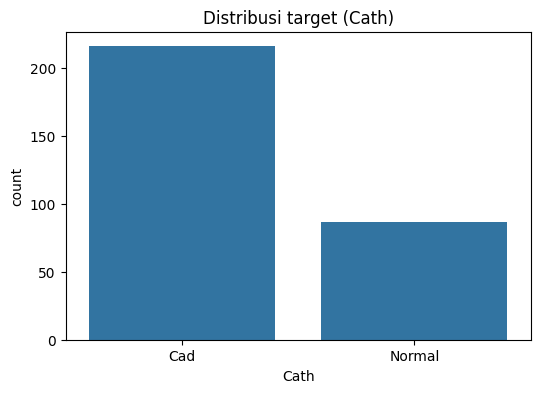

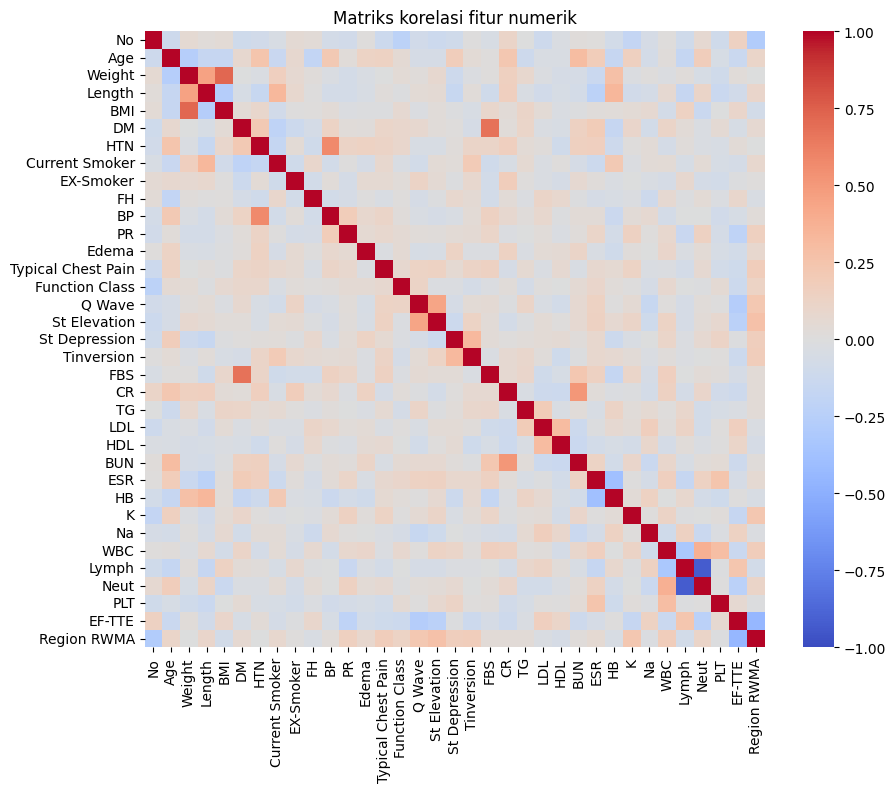

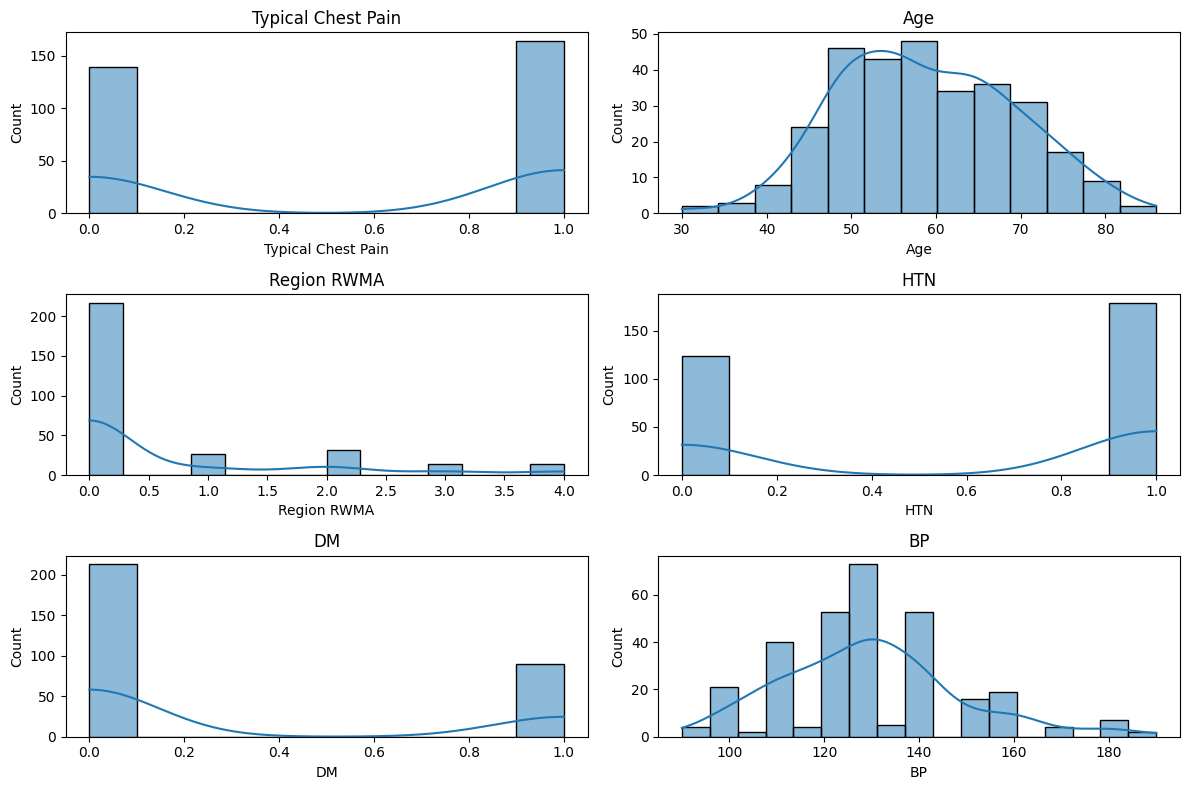

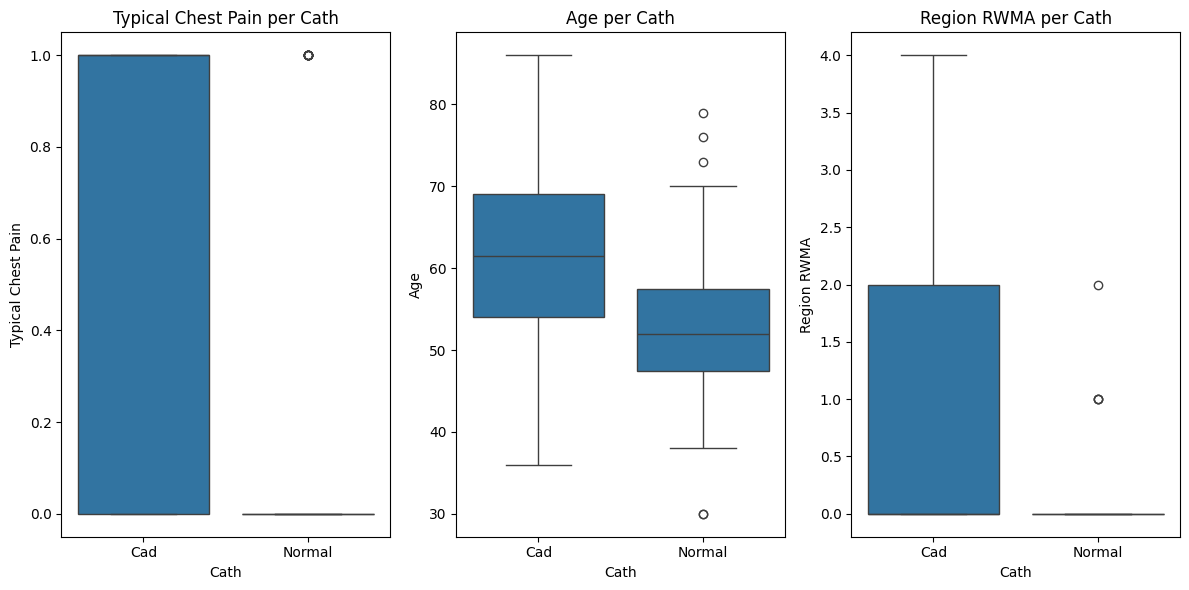

In [3]:
target = 'Cath'

data = df

print('Dimensi (baris, kolom):', data.shape)
print('Jumlah atribut (kolom):', data.shape[1])
print('Jumlah data (baris):', data.shape[0])

print('\nContoh 5 baris awal:')
display(data.head())

print('\nInfo dataset:')
data.info()

print('\nStatistik deskriptif semua kolom:')
display(data.describe(include='all').T)

print('\nJumlah missing value per kolom (top 20):')
display(data.isna().sum().sort_values(ascending=False).head(20))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target in num_cols:
    num_cols.remove(target)

cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
if target in cat_cols:
    cat_cols.remove(target)

print('\nJumlah fitur numerik:', len(num_cols))
print('Jumlah fitur kategorikal:', len(cat_cols))

if target in data.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=data[target].astype(str))
    plt.title(f'Distribusi target ({target})')
    plt.show()

corr_target = pd.Series(dtype=float)
if len(num_cols) >= 1 and target in data.columns:
    y_enc = LabelEncoder().fit_transform(data[target].astype(str))
    df_corr = data[num_cols].copy()
    df_corr['__target_enc'] = y_enc
    corr_target = df_corr.corr()['__target_enc'].drop('__target_enc').abs().sort_values(ascending=False)

if len(num_cols) >= 2:
    plt.figure(figsize=(10,8))
    sns.heatmap(data[num_cols].corr(), cmap='coolwarm', center=0, vmax=1, vmin=-1)
    plt.title('Matriks korelasi fitur numerik')
    plt.show()

top_feats = corr_target.head(6).index.tolist() if not corr_target.empty else []
if top_feats:
    plt.figure(figsize=(12,8))
    for i, col in enumerate(top_feats, 1):
        plt.subplot(3,2,i)
        sns.histplot(data[col].dropna(), kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()

if len(top_feats) >= 3:
    plt.figure(figsize=(12,6))
    for i, col in enumerate(top_feats[:3], 1):
        plt.subplot(1,3,i)
        sns.boxplot(x=data[target].astype(str), y=data[col])
        plt.title(f'{col} per {target}')
    plt.tight_layout()
    plt.show()

## ========================================================================
## 4. Supervised Learning
## ========================================================================

In [4]:
# Preprocessing and feature selection for supervised task
df = df.drop_duplicates()
df = df.dropna()

le = LabelEncoder()
df[target] = le.fit_transform(df[target].astype(str))

# All numeric features except target (for unsupervised)
X_full = df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore')
if 'No' in X_full.columns:
    X_full = X_full.drop(columns=['No'])

# Feature selection for supervised task (predicting `Cath`)
k_sel = min(8, X_full.shape[1])
selector = SelectKBest(mutual_info_classif, k=k_sel)
selector.fit(X_full.fillna(0), df[target])
selected_features = X_full.columns[selector.get_support()].tolist()

print('\nSelected features for target (`Cath`) - top {}:'.format(k_sel))
print(selected_features)

# Supervised feature set (only selected features)
X = X_full[selected_features].copy()

y = df[target]

print('\nUkuran X (supervised):', X.shape)
print('Ukuran X_full (unsupervised):', X_full.shape)
print('Ukuran y:', y.shape)
print('Kolom X (supervised):', X.columns.tolist())
print('Kolom X_full (unsupervised):', X_full.columns.tolist())

# Train-test split (supervised)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Scaling (supervised)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Model training - Supervised Learning
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'MLP': MLPClassifier(max_iter=500, random_state=42),
    'NaiveBayes': GaussianNB()
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

import pandas as _pd
_pd.DataFrame(results).T


Selected features for target (`Cath`) - top 8:
['Age', 'BP', 'PR', 'Typical Chest Pain', 'Tinversion', 'Lymph', 'EF-TTE', 'Region RWMA']

Ukuran X (supervised): (303, 8)
Ukuran X_full (unsupervised): (303, 34)
Ukuran y: (303,)
Kolom X (supervised): ['Age', 'BP', 'PR', 'Typical Chest Pain', 'Tinversion', 'Lymph', 'EF-TTE', 'Region RWMA']
Kolom X_full (unsupervised): ['Age', 'Weight', 'Length', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'BP', 'PR', 'Edema', 'Typical Chest Pain', 'Function Class', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA']


,accuracy,precision,recall,f1
RandomForest,0.828947,0.825626,0.828947,0.817973
MLP,0.815789,0.809211,0.815789,0.806094
NaiveBayes,0.802632,0.805470,0.802632,0.803902


## ========================================================================
## 5. Evaluasi
## ========================================================================

Classification Report - RandomForest
              precision    recall  f1-score   support

           0       0.84      0.94      0.89        54
           1       0.80      0.55      0.65        22

    accuracy                           0.83        76
   macro avg       0.82      0.74      0.77        76
weighted avg       0.83      0.83      0.82        76



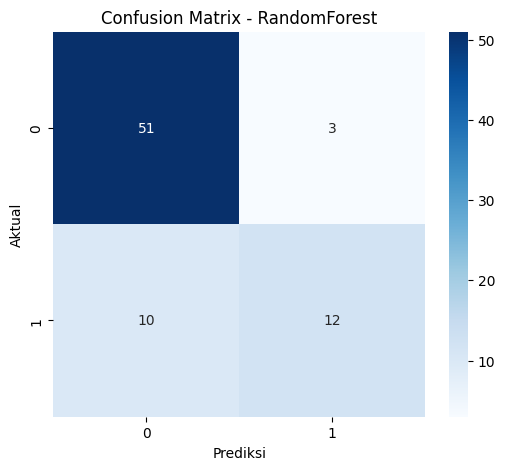

In [5]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print('Classification Report - RandomForest')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RandomForest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Classification Report - MLP
              precision    recall  f1-score   support

           0       0.83      0.93      0.88        54
           1       0.75      0.55      0.63        22

    accuracy                           0.82        76
   macro avg       0.79      0.74      0.75        76
weighted avg       0.81      0.82      0.81        76



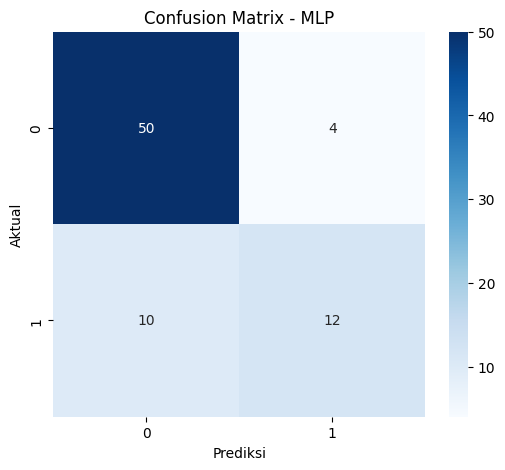

In [6]:
model = MLPClassifier(max_iter=500, random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print('Classification Report - MLP')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - MLP')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Classification Report - NaiveBayes
              precision    recall  f1-score   support

           0       0.87      0.85      0.86        54
           1       0.65      0.68      0.67        22

    accuracy                           0.80        76
   macro avg       0.76      0.77      0.76        76
weighted avg       0.81      0.80      0.80        76



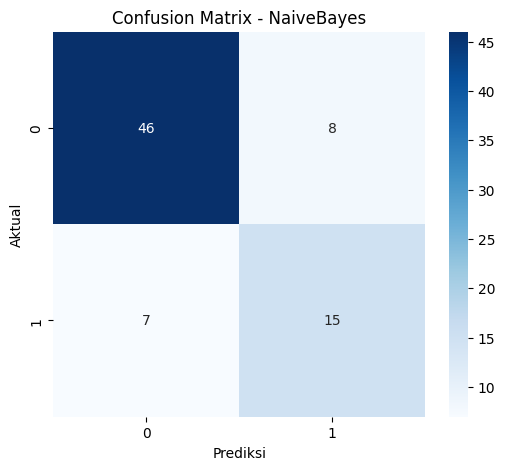

In [7]:
model = GaussianNB()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print('Classification Report - NaiveBayes')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - NaiveBayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## ========================================================================
## 6. Unsupervised Learning: K-Means
## ========================================================================

### STEP 1 - Data Preparation


In [8]:
cluster_df = X_full[['Age']].copy()

features_used = list(cluster_df.columns)

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(cluster_df)


### STEP 2 - Implementasi K-Means Sederhana

In [9]:
def kmeans_simple(X, k=3, max_iter=100, tol=1e-4, random_state=42):
    np.random.seed(random_state)
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    
    for iteration in range(max_iter):
        distances = np.linalg.norm(X[:, None] - centroids[None, :], axis=2)
        labels = np.argmin(distances, axis=1)
        
        new_centroids = np.array([
            X[labels==i].mean(axis=0) if np.any(labels==i) else centroids[i] 
            for i in range(k)
        ])

        if np.linalg.norm(new_centroids - centroids) < tol:
            print(f"Konvergen pada iterasi {iteration + 1}")
            break
        
        centroids = new_centroids
    
    return labels, centroids

### STEP 3 - Elbow Method untuk mencari k optimal

In [10]:
k_max = min(10, X_cluster.shape[0] - 1)
k_range = range(2, k_max + 1)

sse_values = []
silhouette_scores = []
db_indices = []

def davies_bouldin_index(X, labels, centroids):
    k = len(np.unique(labels))
    avg_distances = np.zeros(k)
    for i in range(k):
        pts = X[labels == i]
        if len(pts) > 0:
            avg_distances[i] = np.mean(np.linalg.norm(pts - centroids[i], axis=1))

    db = 0.0
    for i in range(k):
        max_ratio = 0.0
        for j in range(k):
            if i == j:
                continue
            d = np.linalg.norm(centroids[i] - centroids[j])
            if d > 0:
                ratio = (avg_distances[i] + avg_distances[j]) / d
                if ratio > max_ratio:
                    max_ratio = ratio
        db += max_ratio
    return db / k

for k in k_range:
    labels_k, centroids_k = kmeans_simple(X_cluster, k=k)

    sse = sum(np.sum((X_cluster[labels_k == i] - centroids_k[i]) ** 2) for i in range(k))
    sse_values.append(sse)
    try:
        sil = silhouette_score(X_cluster, labels_k) if k > 1 else np.nan
    except Exception:
        sil = np.nan
    silhouette_scores.append(sil)

    db = davies_bouldin_index(X_cluster, labels_k, centroids_k)
    db_indices.append(db)

    print(f"k={k}, SSE={sse:.2f}, Silhouette={sil:.4f}, DB={db:.4f}")

print("Elbow method selesai")

# Ringkasan per-k
import pandas as _pd
summary_df = _pd.DataFrame({
    'k': list(k_range),
    'SSE': sse_values,
    'Silhouette': silhouette_scores,
    'DaviesBouldin': db_indices
})
print('\nTabel ringkasan:')
display(summary_df)

# Pilih k optimal: prioritas Silhouette (lebih tinggi lebih baik), fallback ke DB (lebih rendah lebih baik)
valid_sil = summary_df.dropna(subset=['Silhouette'])
if not valid_sil.empty:
    optimal_k = int(valid_sil.loc[valid_sil['Silhouette'].idxmax(), 'k'])
else:
    optimal_k = int(summary_df.loc[summary_df['DaviesBouldin'].idxmin(), 'k'])

print(f"\n>>> K optimal yang dipilih: {optimal_k}")

Konvergen pada iterasi 6
k=2, SSE=93.64, Silhouette=0.6001, DB=0.5421
Konvergen pada iterasi 4
k=3, SSE=51.58, Silhouette=0.5356, DB=0.5567
Konvergen pada iterasi 3
k=4, SSE=31.34, Silhouette=0.5408, DB=0.5441
Konvergen pada iterasi 5
k=5, SSE=20.92, Silhouette=0.5502, DB=0.5201
Konvergen pada iterasi 5
k=6, SSE=15.40, Silhouette=0.5519, DB=0.5207
Konvergen pada iterasi 6
k=7, SSE=13.44, Silhouette=0.5203, DB=0.5646
Konvergen pada iterasi 6
k=8, SSE=10.82, Silhouette=0.5208, DB=0.5424
Konvergen pada iterasi 8
k=9, SSE=9.96, Silhouette=0.5301, DB=0.5139
Konvergen pada iterasi 9
k=10, SSE=8.61, Silhouette=0.5268, DB=0.5009
Elbow method selesai

Tabel ringkasan:


,k,SSE,Silhouette,DaviesBouldin
0,2,93.639231,0.600100,0.542088
1,3,51.580609,0.535591,0.556705
2,4,31.337932,0.540846,0.544086
3,5,20.919669,0.550170,0.520068
4,6,15.395630,0.551907,0.520669
5,7,13.436969,0.520309,0.564612
6,8,10.815426,0.520778,0.542359
7,9,9.962411,0.530115,0.513945
8,10,8.606315,0.526809,0.500902



>>> K optimal yang dipilih: 2


### STEP 4 - Visualisasi Elbow Method

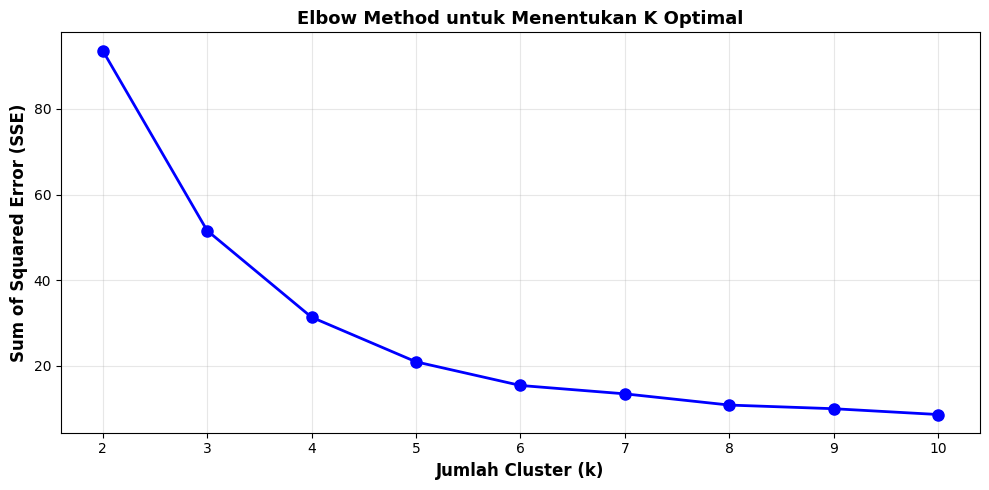

In [11]:


plt.figure(figsize=(10, 5))
plt.plot(list(k_range), sse_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Jumlah Cluster (k)", fontsize=12, fontweight='bold')
plt.ylabel("Sum of Squared Error (SSE)", fontsize=12, fontweight='bold')
plt.title("Elbow Method untuk Menentukan K Optimal", fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

### STEP 5 - Training K-Means dengan k optimal

In [12]:
# Gunakan optimal_k yang ditentukan oleh sel sebelumnya
print(f"Menggunakan optimal_k = {optimal_k}")
labels, centroids = kmeans_simple(X_cluster, k=optimal_k)

Menggunakan optimal_k = 2
Konvergen pada iterasi 6


### STEP 6 - Analisis distribusi cluster

In [13]:
print(f"\nDistribusi anggota cluster:")
unique, counts = np.unique(labels, return_counts=True)

cluster_dist = pd.DataFrame({
    'Cluster': unique,
    'Jumlah Data': counts,
    'Persentase': (counts / len(labels) * 100).round(2)
})

print(cluster_dist.to_string(index=False))


Distribusi anggota cluster:
 Cluster  Jumlah Data  Persentase
       0          162       53.47
       1          141       46.53


### STEP 7 - Visualisasi hasil clustering (2 fitur pertama)

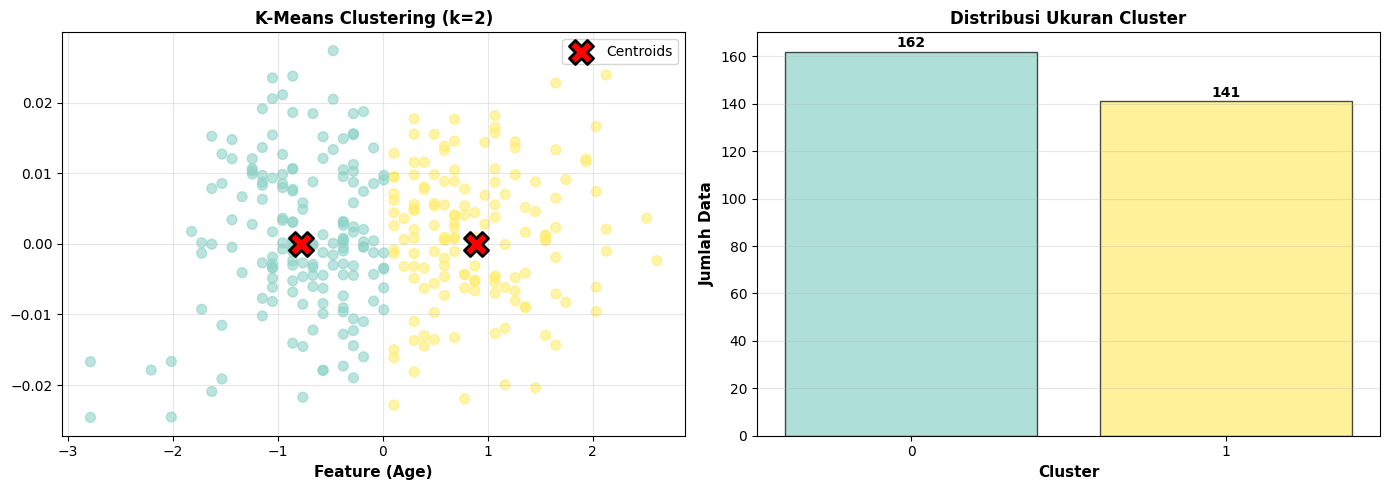

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_features = X_cluster.shape[1]

if n_features == 1:
    x = X_cluster[:, 0]
    y = np.zeros_like(x) + np.random.normal(scale=0.01, size=len(x))
    scatter = axes[0].scatter(x, y, c=labels, cmap='Set3', alpha=0.6, s=50)
    # centroids at y=0
    axes[0].scatter(centroids[:, 0], np.zeros(len(centroids)), marker='X', s=300, c='red',
                    edgecolors='black', linewidths=2, label='Centroids', zorder=5)
    axes[0].set_xlabel(f"Feature ({cluster_df.columns[0]})", fontsize=11, fontweight='bold')
    axes[0].set_ylabel('', fontsize=11)
else:
    scatter = axes[0].scatter(X_cluster[:, 0], X_cluster[:, 1], c=labels, cmap='Set3', alpha=0.6, s=50)
    axes[0].scatter(centroids[:, 0], centroids[:, 1], marker='X', s=300, c='red',
                    edgecolors='black', linewidths=2, label='Centroids', zorder=5)
    axes[0].set_xlabel(f"Feature 0 ({cluster_df.columns[0]})", fontsize=11, fontweight='bold')
    axes[0].set_ylabel(f"Feature 1 ({cluster_df.columns[1]})", fontsize=11, fontweight='bold')

axes[0].set_title(f"K-Means Clustering (k={optimal_k})", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# bar plot (cluster sizes)
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))
axes[1].bar(cluster_dist['Cluster'].astype(str), cluster_dist['Jumlah Data'],
            color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Cluster', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Jumlah Data', fontsize=11, fontweight='bold')
axes[1].set_title('Distribusi Ukuran Cluster', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for i, (cluster, count) in enumerate(zip(cluster_dist['Cluster'], cluster_dist['Jumlah Data'])):
    axes[1].text(i, count + 2, f"{count}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### STEP 8 - Evaluasi kualitas clustering dengan Silhouette Score

In [15]:
from sklearn.metrics import silhouette_score, silhouette_samples

sil_score = silhouette_score(X_cluster, labels)
sil_samples = silhouette_samples(X_cluster, labels)

print(f"\nSilhouette Score: {sil_score:.4f}")
print(f"Interpretasi: {'SANGAT BAIK ' if sil_score > 0.7 else 'BAIK ' if sil_score > 0.5 else 'CUKUP ' if sil_score > 0.25 else 'KURANG BAIK'}")


Silhouette Score: 0.6001
Interpretasi: BAIK 


### STEP 9 - Visualisasi Silhouette Plot

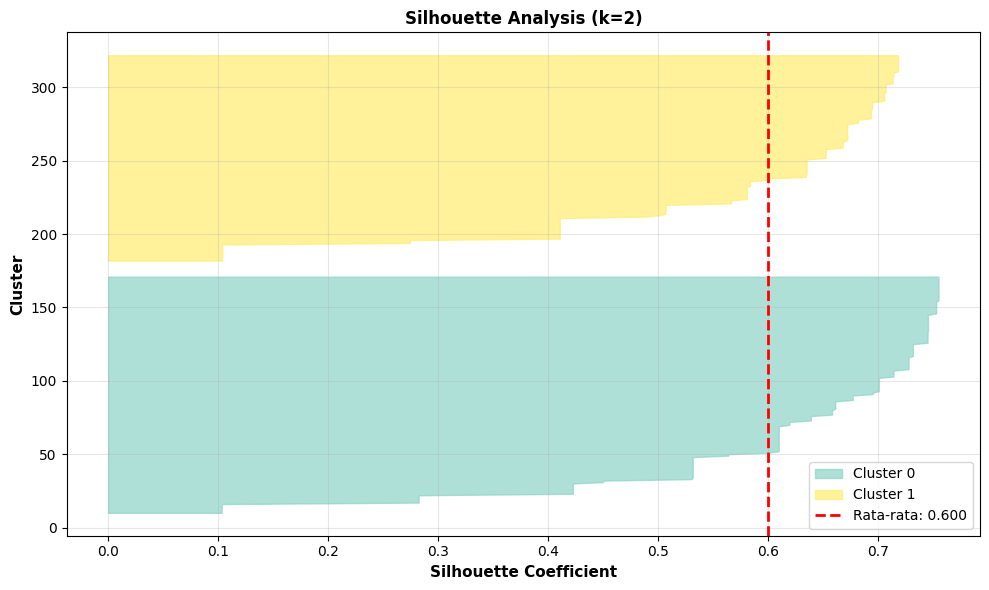

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    cluster_sil_values = sil_samples[labels == i]
    cluster_sil_values.sort()
    
    size_cluster_i = cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_values,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7,
                     label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient', fontsize=11, fontweight='bold')
ax.set_ylabel('Cluster', fontsize=11, fontweight='bold')
ax.axvline(x=sil_score, color="red", linestyle="--", linewidth=2,
           label=f'Rata-rata: {sil_score:.3f}')
ax.set_title(f'Silhouette Analysis (k={optimal_k})', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### STEP 10 - Analisis karakteristik setiap cluster

In [17]:


print(f"\n{'='*80}")
print(f"ANALISIS KARAKTERISTIK CLUSTER")
print(f"{'='*80}\n")

for cluster_id in range(optimal_k):
    cluster_mask = labels == cluster_id
    cluster_data = X_cluster[cluster_mask]
    
    print(f"CLUSTER {cluster_id}:")
    print(f"  Ukuran: {np.sum(cluster_mask)} data ({np.sum(cluster_mask)/len(labels)*100:.1f}%)")
    print(f"  Karakteristik fitur (mean ± std):")
    
    for i, feature in enumerate(cluster_df.columns):
        mean = cluster_data[:, i].mean()
        std = cluster_data[:, i].std()
        print(f"    {feature}: {mean:.4f} ± {std:.4f}")
    print()


ANALISIS KARAKTERISTIK CLUSTER

CLUSTER 0:
  Ukuran: 162 data (53.5%)
  Karakteristik fitur (mean ± std):
    Age: -0.7755 ± 0.5321

CLUSTER 1:
  Ukuran: 141 data (46.5%)
  Karakteristik fitur (mean ± std):
    Age: 0.8910 ± 0.5821

